# 📘 Week 16: Wavelets, ICA & Machine Learning for Signals
Welcome to Week 16 — the **final module** of the Signal Processing Roadmap! In this capstone notebook, we bring together advanced techniques that bridge classical DSP with modern data science.

We will study the **Continuous Wavelet Transform (CWT)** for multi-resolution time-frequency analysis, apply **Independent Component Analysis (ICA)** for blind source separation (the "Cocktail Party Problem"), and build a complete **Machine Learning pipeline** for classifying signals based on extracted DSP features.

## 🎯 Learning Objectives:
- Understand the limitations of STFT's fixed time-frequency resolution and how wavelets overcome them.
- Compute and visualize a CWT scalogram using Morlet and Ricker wavelets.
- Implement blind source separation using FastICA to unmix linearly combined signals.
- Build an end-to-end ML signal classification pipeline: feature extraction → training → evaluation.

## 1. Continuous Wavelet Transform (CWT) vs. STFT
The **Short-Time Fourier Transform (STFT)** uses a fixed window size, leading to a constant time-frequency resolution trade-off:
- A short window gives good time resolution but poor frequency resolution.
- A long window gives good frequency resolution but poor time resolution.

The **Continuous Wavelet Transform (CWT)** overcomes this by using a family of scaled and translated wavelets. At high frequencies (small scales), the wavelet is narrow — giving precise time localization. At low frequencies (large scales), the wavelet is broad — giving precise frequency localization.

$$W(a, b) = \frac{1}{\sqrt{|a|}} \int_{-\infty}^{\infty} x(t) \psi^*\left(\frac{t - b}{a}\right) dt$$

Where $a$ is the scale parameter, $b$ is the translation parameter, and $\psi$ is the mother wavelet.

Let's compare CWT and STFT on a non-stationary chirp signal.

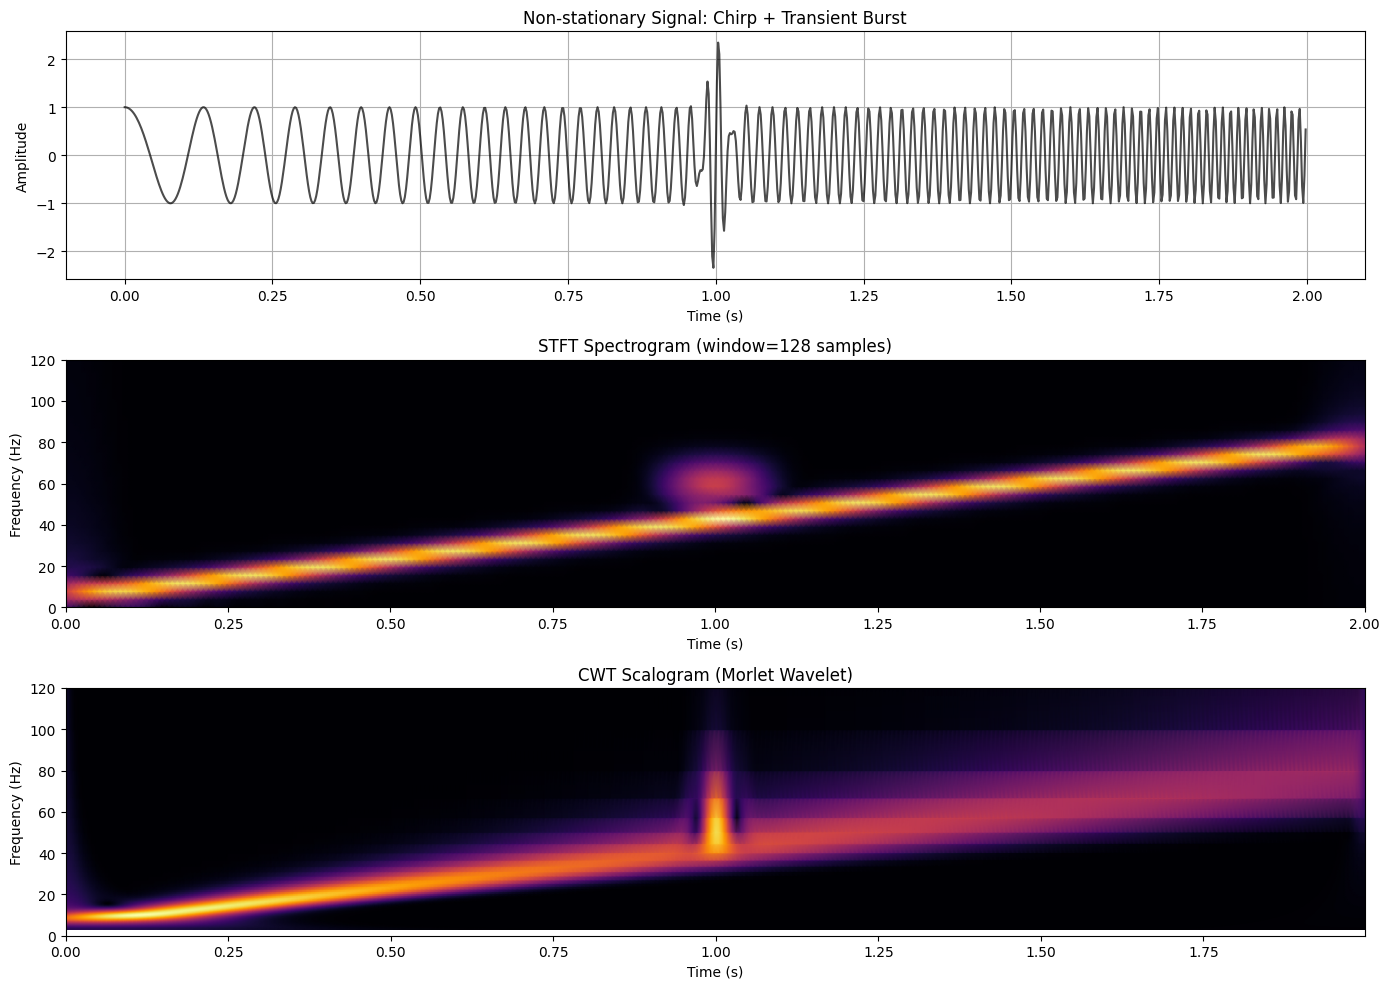

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

# 1. Generate a non-stationary chirp signal (frequency sweeps from 5 Hz to 80 Hz)
fs = 500.0
t = np.linspace(0, 2.0, int(2.0 * fs), endpoint=False)
# Linear chirp: frequency increases linearly from 5 Hz to 80 Hz over 2 seconds
x_chirp = sig.chirp(t, f0=5, f1=80, t1=2.0, method='linear')

# Add a short transient burst at t = 1.0 sec
burst_center = int(1.0 * fs)
burst_env = np.exp(-0.5 * ((t - 1.0) / 0.02)**2)  # Gaussian envelope, sigma=20ms
x_burst = 1.5 * np.sin(2 * np.pi * 60 * t) * burst_env
x = x_chirp + x_burst

# 2. Compute STFT
nperseg = 128
f_stft, t_stft, Zxx = sig.stft(x, fs=fs, nperseg=nperseg, noverlap=nperseg - 4)

# Custom CWT implementation for SciPy 1.15.0+ compatibility
def morlet2(M, s, w=5.0):
    x = np.arange(M) - (M - 1) / 2
    return np.exp(1j * w * x / s) * np.exp(-0.5 * (x / s)**2) * (np.pi**-0.25) * np.sqrt(1 / s)

def cwt(data, wavelet_func, widths, **kwargs):
    output = np.zeros((len(widths), len(data)), dtype=complex)
    for ind, width in enumerate(widths):
        N = int(np.ceil(min(10 * width, len(data))))
        wavelet_data = wavelet_func(N, width, **kwargs)
        kernel = np.conj(wavelet_data)[::-1]
        output[ind, :] = sig.convolve(data, kernel, mode='same')
    return output

# 3. Compute CWT using Morlet wavelet
widths = np.arange(1, 128)
cwtmatr = cwt(x, morlet2, widths, w=5.0)
# Convert widths (scales) to approximate frequencies
freqs_cwt = (5.0 * fs) / (2 * np.pi * widths)

# Plotting comparison
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(t, x, 'black', alpha=0.7)
axes[0].set_title('Non-stationary Signal: Chirp + Transient Burst')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True)

axes[1].pcolormesh(t_stft, f_stft, np.abs(Zxx), shading='gouraud', cmap='inferno')
axes[1].set_title(f'STFT Spectrogram (window={nperseg} samples)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_ylim(0, 120)

axes[2].pcolormesh(t, freqs_cwt, np.abs(cwtmatr), shading='gouraud', cmap='inferno')
axes[2].set_title('CWT Scalogram (Morlet Wavelet)')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Frequency (Hz)')
axes[2].set_ylim(0, 120)

plt.tight_layout()
plt.show()

### Observation:
- In the **STFT** spectrogram, the chirp trace appears as a diagonal line, but the transient burst at $t=1.0$ s is spread out in time (blurred) because the fixed window is too long to precisely localize a 20 ms event.
- In the **CWT** scalogram, the chirp is traced clearly, and the transient burst is sharply localized in time at $t=1.0$ s because high-frequency wavelets are inherently narrow.
- This demonstrates the **multi-resolution** advantage of wavelets.

## 2. Independent Component Analysis (ICA): Blind Source Separation
The **Cocktail Party Problem**: Imagine several independent audio sources (speakers, instruments) recorded by several microphones. Each microphone captures a different linear mixture of the sources. **ICA** recovers the original independent source signals from these mixed observations — without knowing the mixing matrix!

Mathematically, if $\mathbf{s}(t)$ is the vector of $n$ independent source signals and $\mathbf{A}$ is an unknown $n \times n$ mixing matrix:
$$\mathbf{x}(t) = \mathbf{A} \cdot \mathbf{s}(t)$$

ICA finds an unmixing matrix $\mathbf{W}$ such that:
$$\hat{\mathbf{s}}(t) = \mathbf{W} \cdot \mathbf{x}(t)$$

Let's simulate three independent sources, mix them, and recover them using `sklearn.decomposition.FastICA`.

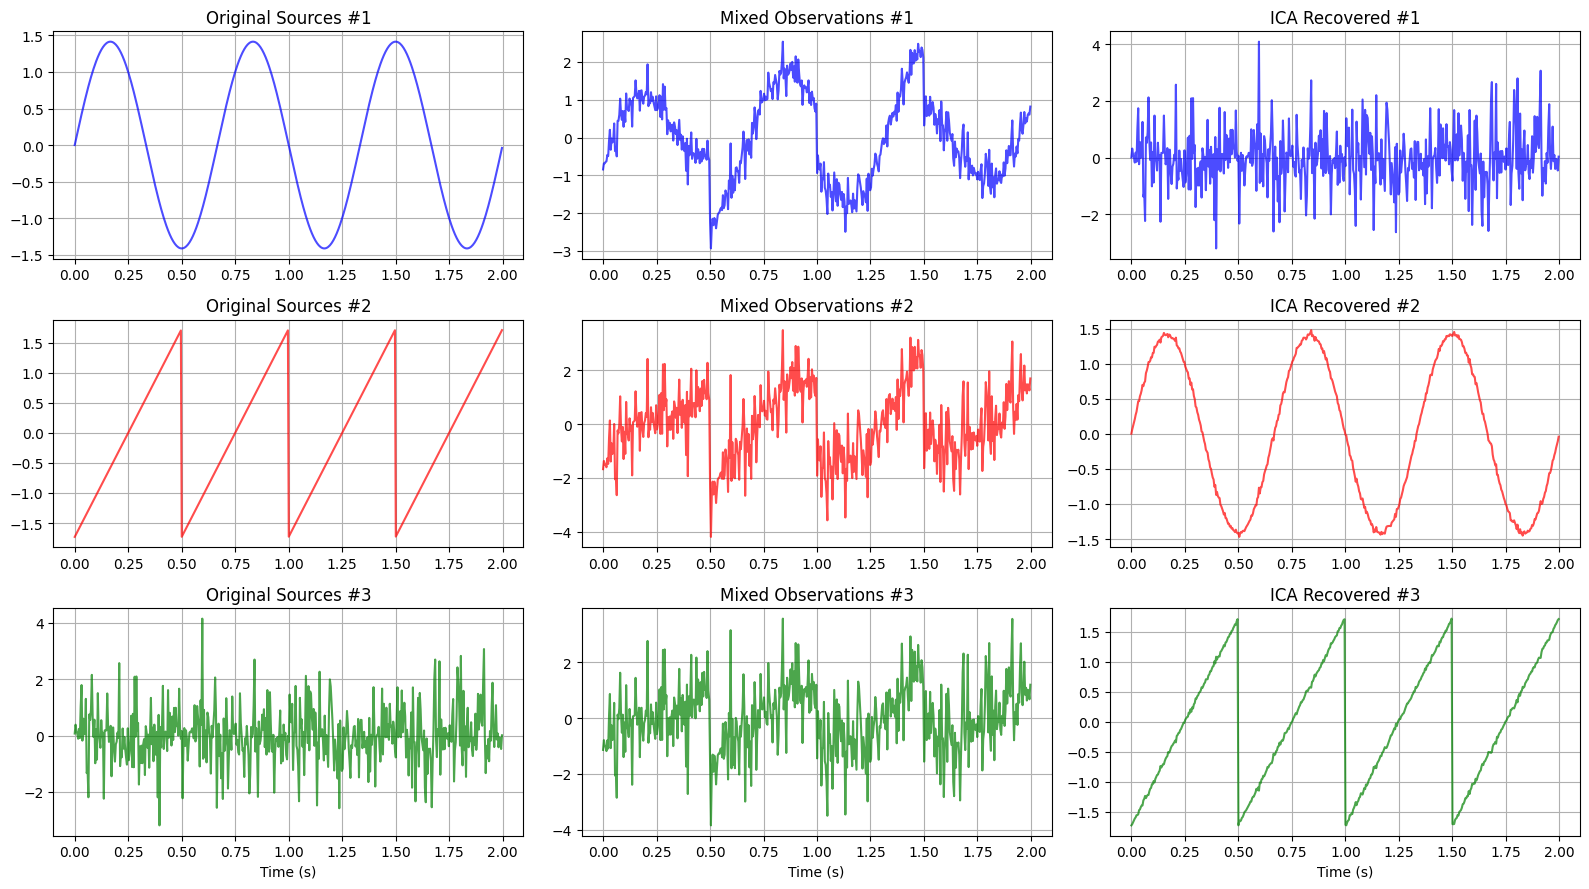

In [2]:
from sklearn.decomposition import FastICA

np.random.seed(0)
n_samples = 2000
t_ica = np.linspace(0, 8, n_samples)

# 1. Generate 3 independent source signals
s1 = np.sin(2 * np.pi * 1.5 * t_ica)                      # Sinusoid (voice-like)
s2 = sig.sawtooth(2 * np.pi * 2.0 * t_ica)                 # Sawtooth (instrument-like)
s3 = np.random.laplace(0, 1.0, n_samples)                  # Impulsive noise

# Normalize sources to unit variance
S = np.c_[s1, s2, s3]
S = S / S.std(axis=0)

# 2. Create a random mixing matrix and mix
A_mix = np.array([[1.0, 0.5, 0.3],
                  [0.5, 1.0, 0.8],
                  [0.3, 0.7, 1.0]])
X = S @ A_mix.T  # Observed mixed signals (3 microphones)

# 3. Apply FastICA to recover sources
ica = FastICA(n_components=3, random_state=0, max_iter=500)
S_recovered = ica.fit_transform(X)

# Plotting: Original Sources, Mixtures, and Recovered Sources
fig, axes = plt.subplots(3, 3, figsize=(16, 9))
titles_col = ['Original Sources', 'Mixed Observations', 'ICA Recovered']
data_col = [S, X, S_recovered]
colors = ['blue', 'red', 'green']

for col in range(3):
    for row in range(3):
        axes[row, col].plot(t_ica[:500], data_col[col][:500, row], color=colors[row], alpha=0.7)
        axes[row, col].set_title(f'{titles_col[col]} #{row+1}')
        axes[row, col].grid(True)
        if row == 2:
            axes[row, col].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

### Observation:
- The **middle column** shows the mixed signals from three simulated microphones — each is a linear superposition of the three sources and looks complex.
- The **right column** shows the ICA-recovered components. Note that ICA recovers the original waveform shapes faithfully, though the **sign** and **order** may be permuted (this is a known ambiguity of ICA).

## 3. Machine Learning Signal Classification
A common real-world task is classifying signal segments (e.g., normal vs. abnormal heartbeat, engine vibration types, or activity recognition from accelerometer data).

The pipeline is:
1. **Generate/Collect** labeled signal segments.
2. **Extract DSP Features** from each segment (e.g., mean, variance, zero-crossing rate, spectral centroid, dominant frequency).
3. **Train a Classifier** (e.g., Random Forest) on the feature vectors.
4. **Evaluate** using accuracy and a confusion matrix.

Let's build this pipeline on synthetic data with 4 signal classes.

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Generate 4 classes of synthetic signals (200 samples each, 256 points per sample)
np.random.seed(42)
n_per_class = 200
seg_len = 256
fs_ml = 256.0
t_seg = np.arange(seg_len) / fs_ml

signals = []
labels = []
class_names = ['Sine', 'Square', 'Chirp', 'Noise']

for i in range(n_per_class):
    freq = np.random.uniform(5, 30)
    noise_amp = 0.1
    # Class 0: Sine wave
    signals.append(np.sin(2 * np.pi * freq * t_seg) + noise_amp * np.random.randn(seg_len))
    labels.append(0)
    # Class 1: Square wave
    signals.append(sig.square(2 * np.pi * freq * t_seg) + noise_amp * np.random.randn(seg_len))
    labels.append(1)
    # Class 2: Chirp
    signals.append(sig.chirp(t_seg, f0=5, f1=60, t1=1.0) + noise_amp * np.random.randn(seg_len))
    labels.append(2)
    # Class 3: Random noise
    signals.append(np.random.randn(seg_len))
    labels.append(3)

signals = np.array(signals)
labels = np.array(labels)
print(f"Dataset shape: {signals.shape}, Labels: {np.unique(labels, return_counts=True)}")

Dataset shape: (800, 256), Labels: (array([0, 1, 2, 3]), array([200, 200, 200, 200]))


In [4]:
# 2. Feature Extraction Function
def extract_features(segment, sampling_rate):
    # Time-domain features
    mean_val = np.mean(segment)
    std_val = np.std(segment)
    rms_val = np.sqrt(np.mean(segment**2))
    
    # Zero-Crossing Rate
    zero_crossings = np.sum(np.diff(np.sign(segment)) != 0)
    zcr = zero_crossings / len(segment)
    
    # Frequency-domain features
    fft_vals = np.abs(np.fft.rfft(segment))
    freqs = np.fft.rfftfreq(len(segment), 1.0 / sampling_rate)
    
    # Spectral Centroid
    spectral_centroid = np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-10)
    
    # Dominant Frequency
    dominant_freq = freqs[np.argmax(fft_vals[1:]) + 1]  # Skip DC
    
    # Spectral Energy
    spectral_energy = np.sum(fft_vals**2)
    
    # Spectral Roll-off (85th percentile)
    cumsum = np.cumsum(fft_vals)
    rolloff_idx = np.searchsorted(cumsum, 0.85 * cumsum[-1])
    spectral_rolloff = freqs[min(rolloff_idx, len(freqs) - 1)]
    
    return [mean_val, std_val, rms_val, zcr, spectral_centroid, dominant_freq, spectral_energy, spectral_rolloff]

# Extract features for all signals
feature_names = ['Mean', 'Std', 'RMS', 'ZCR', 'Spectral Centroid', 'Dominant Freq', 'Spectral Energy', 'Spectral Rolloff']
X_features = np.array([extract_features(s, fs_ml) for s in signals])
print(f"Feature matrix shape: {X_features.shape}")
print(f"Feature names: {feature_names}")

Feature matrix shape: (800, 8)
Feature names: ['Mean', 'Std', 'RMS', 'ZCR', 'Spectral Centroid', 'Dominant Freq', 'Spectral Energy', 'Spectral Rolloff']


Classification Accuracy: 100.0%


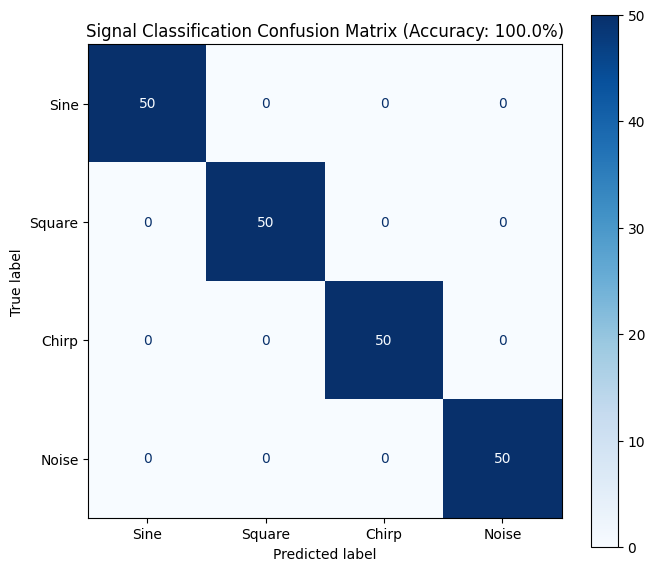

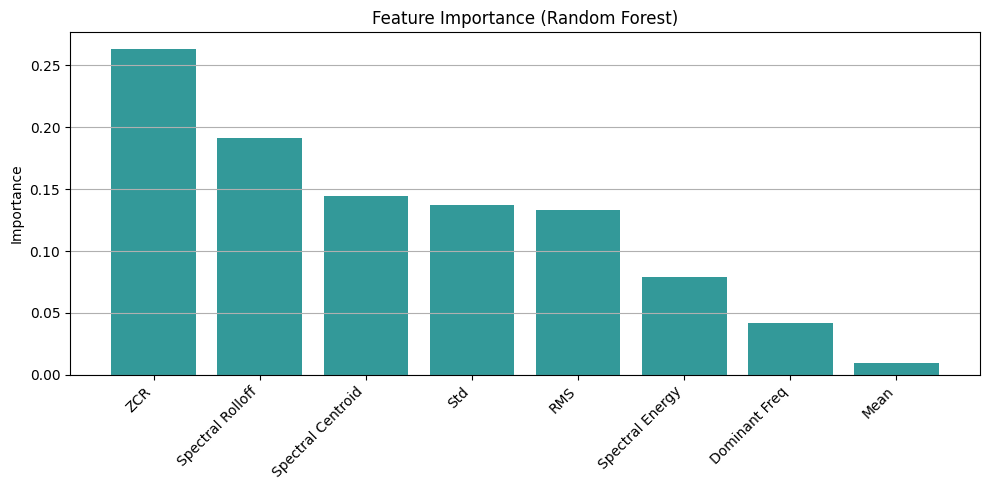

In [5]:
# 3. Train/Test Split and Random Forest Classification
X_train, X_test, y_train, y_test = train_test_split(X_features, labels, test_size=0.25, random_state=42, stratify=labels)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Classification Accuracy: {acc * 100:.1f}%")

# 4. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f"Signal Classification Confusion Matrix (Accuracy: {acc*100:.1f}%)")
plt.tight_layout()
plt.show()

# 5. Feature Importance
importances = clf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_names)), importances[sorted_idx], color='teal', alpha=0.8)
plt.xticks(range(len(feature_names)), [feature_names[i] for i in sorted_idx], rotation=45, ha='right')
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## ✅ Reflection & Exercises
- **Wavelet Families**: Implement a custom Ricker (Mexican Hat) wavelet function: `def ricker(points, a): points = np.arange(points) - (points - 1) / 2; a_sq = a**2; x_sq = points**2; A = 2 / (np.sqrt(3 * a) * (np.pi**0.25)); return A * (1 - x_sq / a_sq) * np.exp(-x_sq / (2 * a_sq))`. Replace the Morlet wavelet in Section 1 with this Ricker wavelet and compute/plot the scalogram. How does it change? Which wavelet gives better frequency localization?
- **ICA Limitations**: What happens if the number of sources exceeds the number of observed mixtures (underdetermined ICA)? Try setting `n_components=2` in FastICA while keeping 3 sources. What goes wrong?
- **Feature Engineering**: Add more features to Section 3 (e.g., signal kurtosis, skewness, spectral flatness). Does the classification accuracy improve?

---

## 🎉 Congratulations!
You have completed the entire **16-week Signal Processing Roadmap**! You have covered:
- Signals, systems, and transforms (Fourier, Laplace, Z)
- Sampling theory, aliasing, and digital filters (FIR/IIR)
- Spectral analysis (FFT, STFT, Spectrograms, Wavelets)
- Real-world applications: Audio, Speech, Biomedical (ECG/EEG), Radar, Communications, IoT, Finance
- Advanced techniques: ICA, Kalman Filters, Machine Learning for Signals, Embedded DSP

Keep exploring, building projects, and applying these techniques to real-world datasets!